# Это мой икм по временным рядам, не судите строго (ну пожалуйста, иначе я заплачу...)

## Выполнила Мельникова Софья группа ИТ/О ИТ-3-2023 НБ

In [1]:
# =============================================================================
# 1. значинаем с анализа самого датасета (Exchange)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# названия валют (признаки)
column_names = ['AUD', 'GBP', 'CAD', 'CHF', 'CNY', 'JPY', 'NZD', 'SGD']

# загружаем данные
df = pd.read_csv('exchange_rate.txt', header=None, names=column_names)

# добавляем номер дня (индекс времени)
df['day'] = range(1, len(df) + 1)

# =============================================================================
# 1.1 + 1.2 + 1.3 описание датасета и размер выборки и описание признаков
# =============================================================================
print("~" * 50)
print(" "*15 + "Описание датасета")
print("~" * 50)

print("""
Данные: ежедневные курсы 8 валют
Период: примерно 1990-2016 годы (как написано в карточке датасета на кегле)

Валюты: AUD, GBP, CAD, CHF, CNY, JPY, NZD, SGD
австралийский дол, фунт стерлинг, канадский дол, швейцарский франк, китайский юань, японская йена, нов. зел. дол., сингапурский дол.
   (относительно доллара США)
""")

print(f"Размер выборки: {len(df)} дней (строк)")
print(f"Количество признаков: 8 валют")
print(f"Пропусков в данных: {df[column_names].isnull().sum().sum()}")
print(f"Первые 3 дня:\n{df[column_names].head(3)}\n ")
print(f"Последние 3 дня:\n{df[column_names].tail(3)}")

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
               Описание датасета
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Данные: ежедневные курсы 8 валют
Период: примерно 1990-2016 годы (как написано в карточке датасета на кегле)

Валюты: AUD, GBP, CAD, CHF, CNY, JPY, NZD, SGD
австралийский дол, фунт стерлинг, канадский дол, швейцарский франк, китайский юань, японская йена, нов. зел. дол., сингапурский дол.
   (относительно доллара США)

Размер выборки: 7588 дней (строк)
Количество признаков: 8 валют
Пропусков в данных: 0
Первые 3 дня:
      AUD     GBP       CAD       CHF       CNY       JPY     NZD       SGD
0  0.7855  1.6110  0.861698  0.634196  0.211242  0.006838  0.5930  0.525486
1  0.7818  1.6100  0.861104  0.633513  0.211242  0.006863  0.5940  0.523972
2  0.7867  1.6293  0.861030  0.648508  0.211242  0.006975  0.5973  0.526316
 
Последние 3 дня:
           AUD       GBP       CAD       CHF       CNY       JPY       NZD  \
7585  0.723197  1.234111  0.745184  0.9844

In [2]:
# =============================================================================
# 1.3 проверка стационарности
# =============================================================================
print("~" * 50)
print(" "*15 + "Стационарность рядов")
print("~" * 50)

# функция для быстрой проверки, смотрим на график и считаем среднее по частям
def is_stationary_simple(series, name):
    # разбиваем ряд на 2 половины и сравниваем средние
    mid = len(series) // 2
    mean_first = series[:mid].mean()
    mean_second = series[mid:].mean()
    diff_percent = abs(mean_first - mean_second) / mean_first * 100
    
    if diff_percent > 10:
        status = "НЕстационарный (среднее сильно меняется)"
    else:
        status = "         Стационарный (среднее стабильно)"
    
    print(f"   {name}: {status} (изменение среднего: {diff_percent:.1f}%)")
    return diff_percent

print("Простая проверка (сравнение среднего в начале и конце):")
for col in column_names:
    is_stationary_simple(df[col], col)

print("\n Вывод: Большинство валютных рядов НЕстационарны,")
print("   т.к. курсы меняются со временем (тренд)")
print("   далее данные для удобства нужно будет преобразовать")

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
               Стационарность рядов
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Простая проверка (сравнение среднего в начале и конце):
   AUD: НЕстационарный (среднее сильно меняется) (изменение среднего: 25.9%)
   GBP:          Стационарный (среднее стабильно) (изменение среднего: 0.5%)
   CAD: НЕстационарный (среднее сильно меняется) (изменение среднего: 22.8%)
   CHF: НЕстационарный (среднее сильно меняется) (изменение среднего: 38.0%)
   CNY:          Стационарный (среднее стабильно) (изменение среднего: 8.4%)
   JPY: НЕстационарный (среднее сильно меняется) (изменение среднего: 16.1%)
   NZD: НЕстационарный (среднее сильно меняется) (изменение среднего: 28.8%)
   SGD: НЕстационарный (среднее сильно меняется) (изменение среднего: 19.2%)

 Вывод: Большинство валютных рядов НЕстационарны,
   т.к. курсы меняются со временем (тренд)
   далее данные для удобства нужно будет преобразовать



ВИЗУАЛИЗАЦИЯ


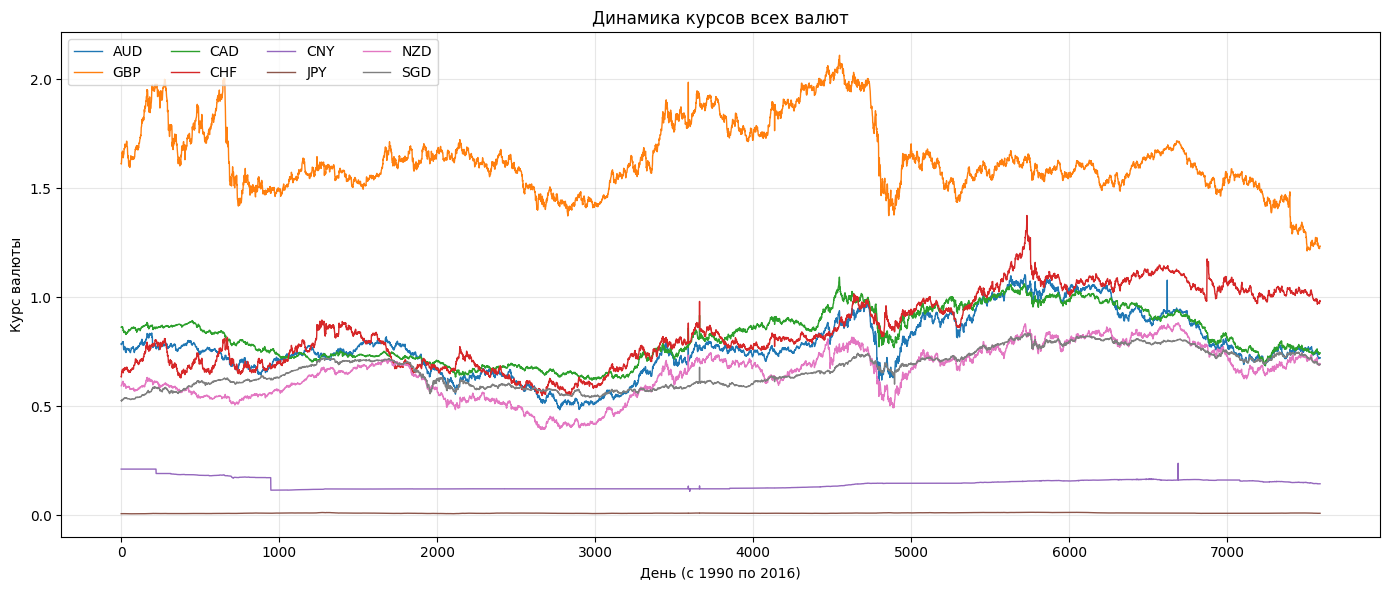

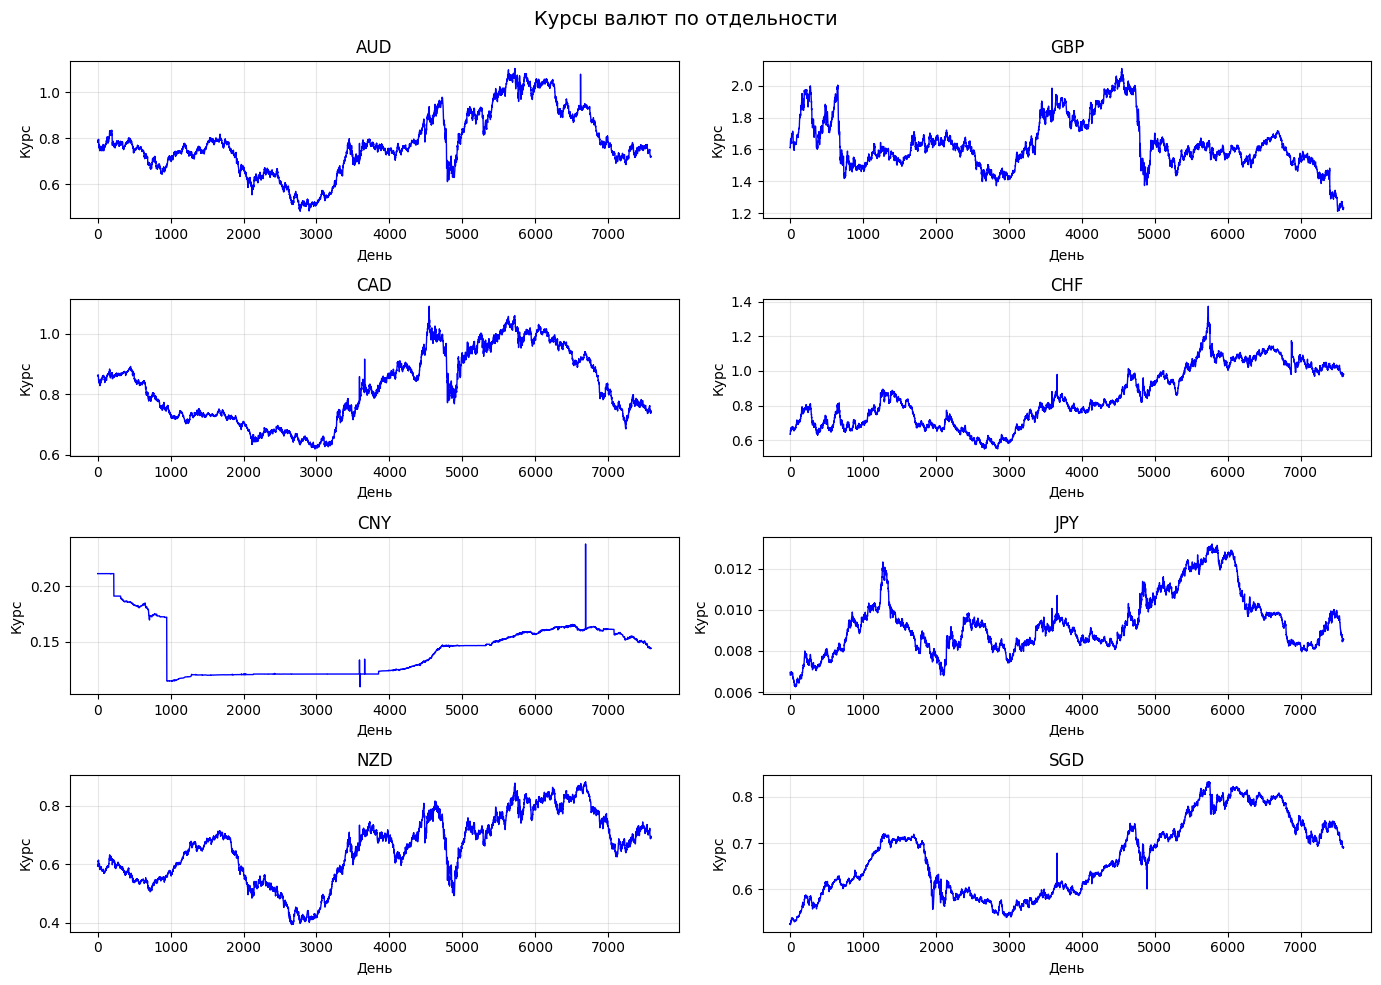

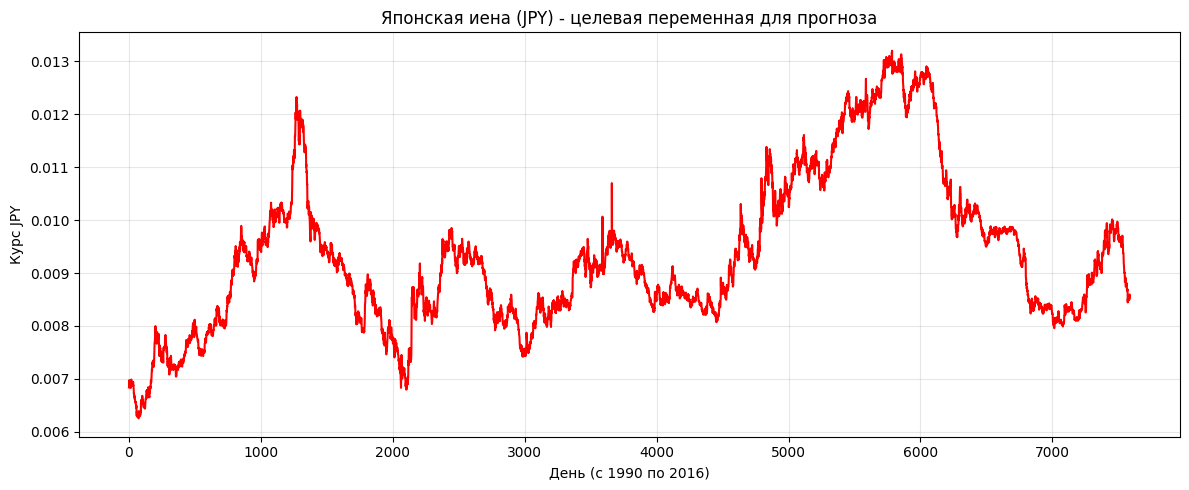


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
               промежуточные выводы
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Данные:
   - 8 валютных курсов за ~6500 дней (1990-2016)
   - Нет пропусков, данные чистые

Признаки:
   - AUD, GBP, CAD, CHF, CNY, JPY, NZD, SGD
   - Целевая переменная для прогноза: JPY (японская иена)

Стационарность:
   - Ряды в большинстве нестационарны (есть тренд и изменение среднего) ((нормально для валют))

Визуализация:
   - Некоторые валюты движутся вместе (AUD и NZD оочень похожи)
   - CNY долгое время был стабилен



In [3]:
print("\n" + "=" * 50)
print("ВИЗУАЛИЗАЦИЯ")
print("=" * 50)

# График 1: Все валюты вместе
plt.figure(figsize=(14, 6))
for col in column_names:
    plt.plot(df['day'], df[col], label=col, linewidth=1)
plt.xlabel('День (с 1990 по 2016)')
plt.ylabel('Курс валюты')
plt.title('Динамика курсов всех валют')
plt.legend(loc='upper left', ncol=4)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('graph1_all_currencies.png')
plt.show()

# График 2: Каждая валюта отдельно (2 строки, 4 столбца)
fig, axes = plt.subplots(4, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(column_names):
    axes[i].plot(df['day'], df[col], color='blue', linewidth=1)
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel('День')
    axes[i].set_ylabel('Курс')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Курсы валют по отдельности', fontsize=14)
plt.tight_layout()
plt.savefig('graph2_separate.png')
plt.show()

# График 3: Целевая валюта JPY (её будем прогнозировать)
plt.figure(figsize=(12, 5))
plt.plot(df['day'], df['JPY'], color='red', linewidth=1.5)
plt.xlabel('День (с 1990 по 2016)')
plt.ylabel('Курс JPY')
plt.title('Японская иена (JPY) - целевая переменная для прогноза')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('graph3_jpy.png')
plt.show()


print("\n" + "~" * 50)
print(" "*15+"промежуточные выводы")
print("~" * 50)

print("""
Данные:
   - 8 валютных курсов за ~6500 дней (1990-2016)
   - Нет пропусков, данные чистые

Признаки:
   - AUD, GBP, CAD, CHF, CNY, JPY, NZD, SGD
   - Целевая переменная для прогноза: JPY (японская иена)

Стационарность:
   - Ряды в большинстве нестационарны (есть тренд и изменение среднего) ((нормально для валют))

Визуализация:
   - Некоторые валюты движутся вместе (AUD и NZD оочень похожи)
   - CNY долгое время был стабилен
""")


In [4]:
# =============================================================================
# 2. предобработка и feauture extraction
# =============================================================================

#import pandas as pd
#import numpy as np
#import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Загружаем данные (если не загружены)
column_names = ['AUD', 'GBP', 'CAD', 'CHF', 'CNY', 'JPY', 'NZD', 'SGD']
df = pd.read_csv('exchange_rate.txt', header=None, names=column_names)


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
               Предобработка данных
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 Целевая переменная: JPY
 Признаки для прогноза: ['AUD', 'GBP', 'CAD', 'CHF', 'CNY', 'NZD', 'SGD']
   Encoding: не требуется (все признаки числовые)
   Interpolation: не требуется (нет пропусков)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
       Декомпозиция временного ряда (JPY)
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


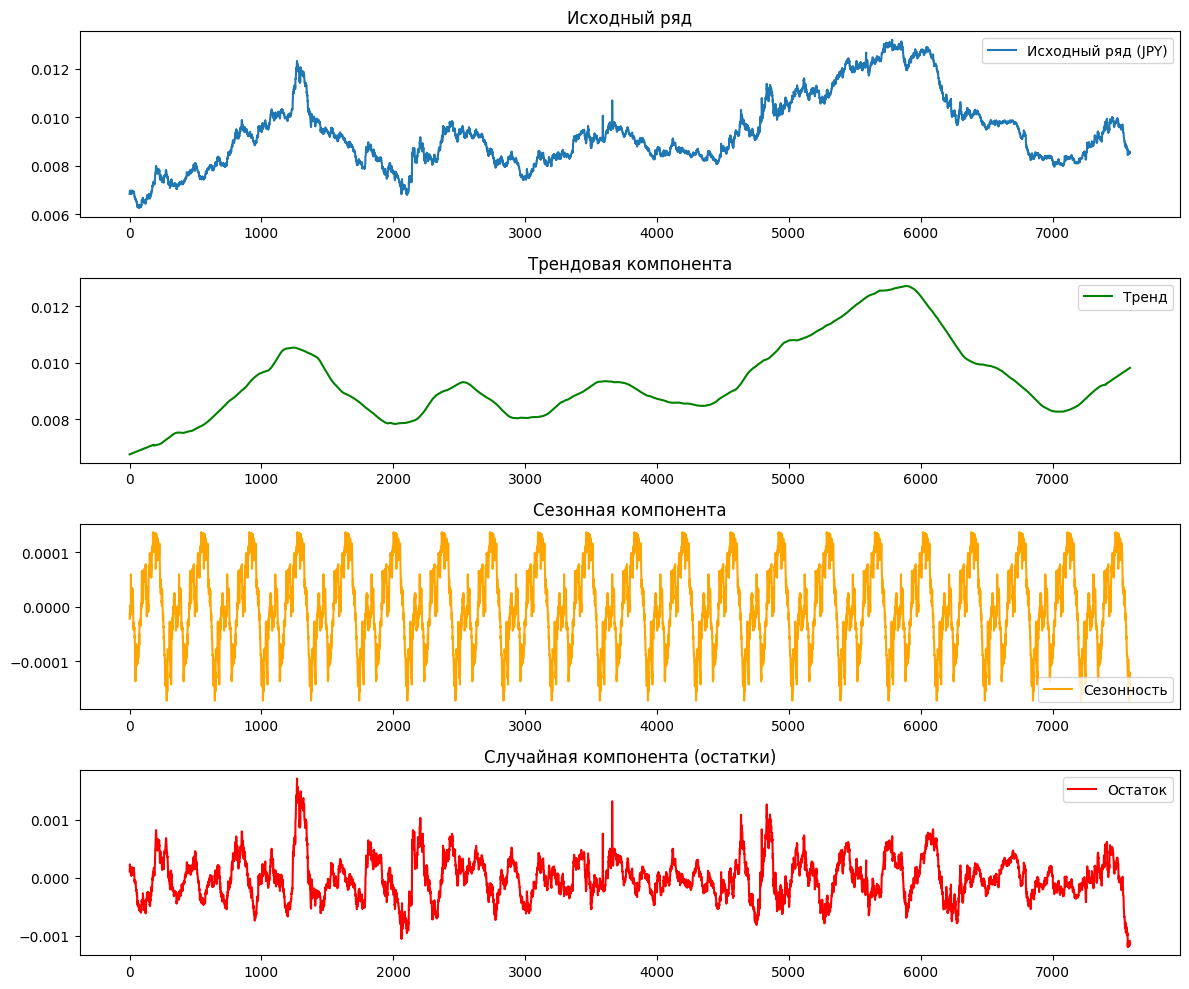

Ряд имеет явно выраженный тренд, сезонность слабая (нормально для валют)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
       Автокорреляционный анализ (JPY)
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


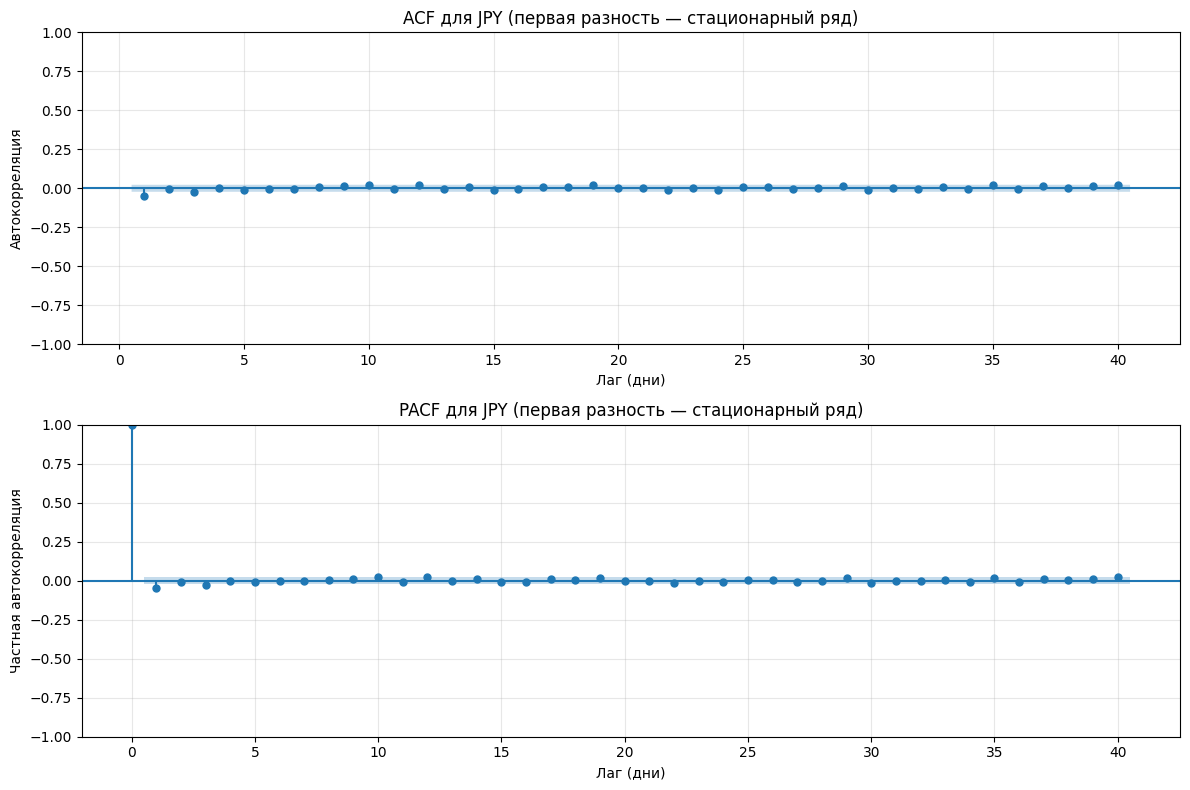


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
          Анализ выбросов (Boxplot)
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


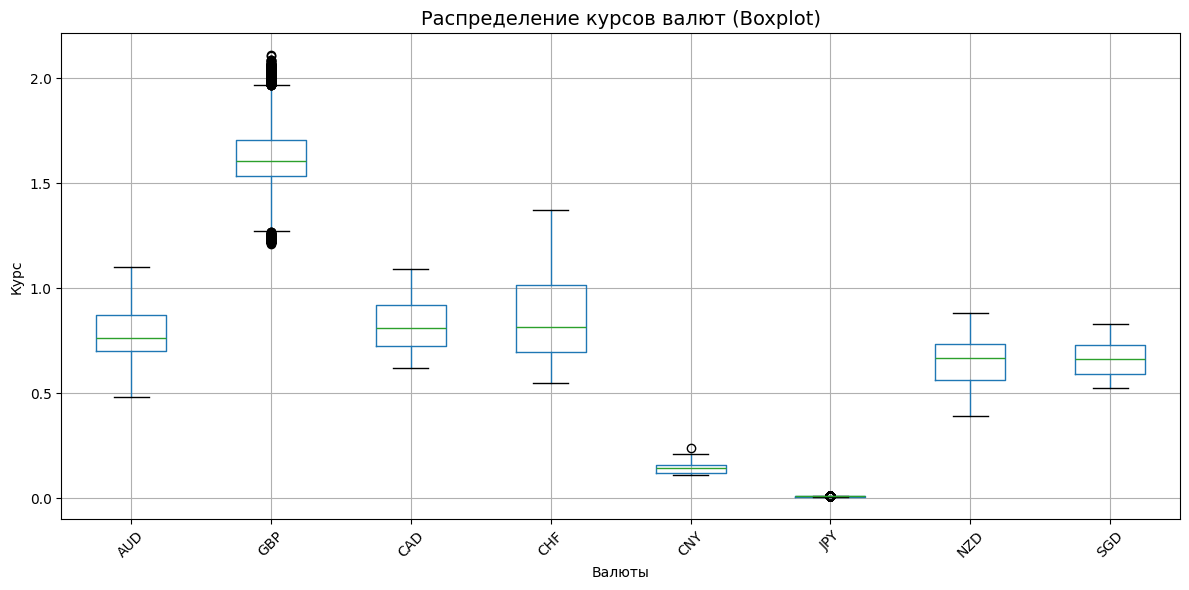

Вывод: Точки за 'усами' — выбросы (кризисные периоды)
 Выбросы не удаляем, так как они несут важную информацию


In [5]:
print("~" * 50)
print(" " * 15 + "Предобработка данных")
print("~" * 50)

# =============================================================================
# целевая переменная японская йена
# =============================================================================
target = 'JPY'
features = [col for col in column_names if col != target]

print(f" Целевая переменная: {target}")
print(f" Признаки для прогноза: {features}")
print("   Encoding: не требуется (все признаки числовые)")
print("   Interpolation: не требуется (нет пропусков)")

# =============================================================================
# декомпозиция ряда (тренд + сезонность + остаток)
# =============================================================================
print("\n" + "~" * 50)
print(" "*7+"Декомпозиция временного ряда (JPY)")
print("~" * 50)

from statsmodels.tsa.seasonal import seasonal_decompose

jpy_series = df['JPY']

try:
    decomposition = seasonal_decompose(jpy_series, model='additive', period=365, extrapolate_trend='freq')
    
    fig, axes = plt.subplots(4, 1, figsize=(12, 10))
    
    axes[0].plot(jpy_series, label='Исходный ряд (JPY)')
    axes[0].set_title('Исходный ряд')
    axes[0].legend()
    
    axes[1].plot(decomposition.trend, label='Тренд', color='green')
    axes[1].set_title('Трендовая компонента')
    axes[1].legend()
    
    axes[2].plot(decomposition.seasonal, label='Сезонность', color='orange')
    axes[2].set_title('Сезонная компонента')
    axes[2].legend()
    
    axes[3].plot(decomposition.resid, label='Остаток', color='red')
    axes[3].set_title('Случайная компонента (остатки)')
    axes[3].legend()
    
    plt.tight_layout()
    plt.savefig('decomposition.png', dpi=150)
    plt.show()
    
    print("Ряд имеет явно выраженный тренд, сезонность слабая (нормально для валют)")
    
except Exception as e:
    print(f"Декомпозиция не выполнена: {e}")

# =============================================================================
# автокорреляция (ACF/PACF)
# =============================================================================
print("\n" + "~" * 50)
print(" "*7+"Автокорреляционный анализ (JPY)")
print("~" * 50)

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

jpy_diff = jpy_series.diff().dropna()  # первая разность → стационарный ряд


plot_acf(jpy_diff, lags=40, ax=ax1, alpha=0.05, zero=False)
ax1.set_title('ACF для JPY (первая разность — стационарный ряд)')
#plot_acf(jpy_series, lags=40, ax=ax1, alpha=0.05)
#ax1.set_title('ACF (автокорреляционная функция) для JPY')
ax1.set_xlabel('Лаг (дни)')
ax1.set_ylabel('Автокорреляция')
ax1.grid(True, alpha=0.3)

plot_pacf(jpy_diff, lags=40, ax=ax2, alpha=0.05, method='ywm')
ax2.set_title('PACF для JPY (первая разность — стационарный ряд)')
#plot_pacf(jpy_series, lags=40, ax=ax2, alpha=0.05, method='ywm')
#ax2.set_title('PACF (частная автокорреляционная функция) для JPY')
ax2.set_xlabel('Лаг (дни)')
ax2.set_ylabel('Частная автокорреляция')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('acf_pacf.png', dpi=150)
plt.show()

#print("Вывод по ACF/PACF: график получился неинформативным")

# =============================================================================
#  ящик с усами (выбросы)
# =============================================================================
print("\n" + "~" * 50)
print(" "*10+"Анализ выбросов (Boxplot)")
print("~" * 50)

fig, ax = plt.subplots(figsize=(12, 6))
df[column_names].boxplot(ax=ax)
ax.set_title('Распределение курсов валют (Boxplot)', fontsize=14)
ax.set_ylabel('Курс')
ax.set_xlabel('Валюты')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('boxplot.png', dpi=150)
plt.show()

print("Вывод: Точки за 'усами' — выбросы (кризисные периоды)")
print(" Выбросы не удаляем, так как они несут важную информацию")

In [6]:
# =============================================================================
# 2.2 создание признаков (feauture extraction) с помощью трех методов
# =============================================================================
print("\n" + "~" * 50)
print(" "*11 +"feauture extraction 3 метода")
print("~" * 50)

# копируем данные для признаков
df_features = df[features].copy()

# Метод 1: Lag features (значения за предыдущие дни)
print("\n    1. Lag features (значения за предыдущие 1, 2, 3 дня) \n ")
for lag in [1, 2, 3]:
    for col in features:
        df_features[f'{col}_lag{lag}'] = df[col].shift(lag)
    print(f"   Добавлены лаги 1,2,3 для {len(features)} валют → +{len(features)*3} признаков")

# Метод 2: Rolling statistics (скользящие средние)
print("\n    2. Rolling statistics (скользящие средние за 5 и 10 дней) \n")
for window in [5, 10]:
    for col in features:
        df_features[f'{col}_roll_mean_{window}'] = df[col].rolling(window=window).mean()
    print(f"   Добавлены скользящие средние (window={window}) для {len(features)} валют → +{len(features)} признаков")

# Метод 3: Diff (разность) для стационарности
print("\n    3. Diff (разность между текущим и предыдущим днем) \n")
for col in features:
    df_features[f'{col}_diff'] = df[col].diff()
print(f"   Добавлены разности для {len(features)} валют → +{len(features)} признаков")

# добавляем целевую переменную
df_features[target] = df[target]

# удаляем строки с NaN (первые строки из-за лагов и разностей)
df_features = df_features.dropna().reset_index(drop=True)

print(f"\n Итоговый размер данных после создания признаков: {df_features.shape} \n")
print(f"   Строк: {df_features.shape[0]}")
print(f"   Столбцов: {df_features.shape[1]} (включая целевую переменную)")


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
           feauture extraction 3 метода
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

    1. Lag features (значения за предыдущие 1, 2, 3 дня) 
 
   Добавлены лаги 1,2,3 для 7 валют → +21 признаков
   Добавлены лаги 1,2,3 для 7 валют → +21 признаков
   Добавлены лаги 1,2,3 для 7 валют → +21 признаков

    2. Rolling statistics (скользящие средние за 5 и 10 дней) 

   Добавлены скользящие средние (window=5) для 7 валют → +7 признаков
   Добавлены скользящие средние (window=10) для 7 валют → +7 признаков

    3. Diff (разность между текущим и предыдущим днем) 

   Добавлены разности для 7 валют → +7 признаков

 Итоговый размер данных после создания признаков: (7579, 50) 

   Строк: 7579
   Столбцов: 50 (включая целевую переменную)


In [7]:
# =============================================================================
# 2.3 масштабирование (MinMaxScaler)
# =============================================================================
print("\n" + "~" * 50)
print( " " * 14 + "Масштабирование данных")
print("~" * 50)

# отделяем признаки (X) и целевую переменную (y)
X = df_features.drop(columns=[target]).values
y = df_features[target].values

# масштабируем признаки в диапазон [0, 1]
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)

# масштабируем целевую переменную
scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

print(f" Признаки масштабированы: {X_scaled.shape}")
print(f" Целевая переменная масштабирована: {y_scaled.shape}")

# =============================================================================
# 2.4 разбиение на обучающую (80%) и тестовую (20%) выборку
# =============================================================================
print("\n" + "~" * 50)
print(" " * 12 +"Разделение на train/test")
print("~" * 50)

# для временных рядов берем последовательные блоки, а не перемешиваем
train_size = int(len(X_scaled) * 0.8)

X_train = X_scaled[:train_size]
X_test = X_scaled[train_size:]
y_train = y_scaled[:train_size]
y_test = y_scaled[train_size:]

print(f" Обучающая выборка: {X_train.shape[0]} строк ({train_size/len(X_scaled)*100:.0f}%)")
print(f" Тестовая выборка: {X_test.shape[0]} строк ({100 - train_size/len(X_scaled)*100:.0f}%)")
print(f" Количество признаков для модели: {X_train.shape[1]}")


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
              Масштабирование данных
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 Признаки масштабированы: (7579, 49)
 Целевая переменная масштабирована: (7579,)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
            Разделение на train/test
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 Обучающая выборка: 6063 строк (80%)
 Тестовая выборка: 1516 строк (20%)
 Количество признаков для модели: 49


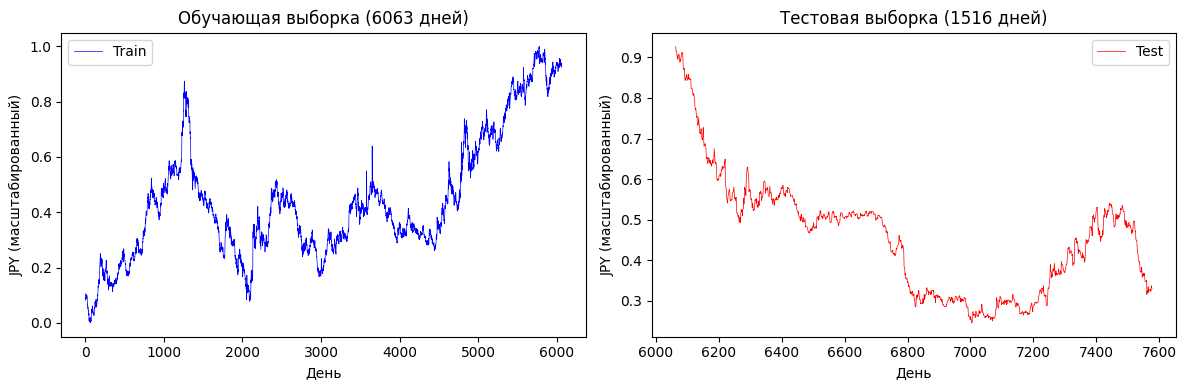


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
             Вновь промежуточные итоги
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

   1. Целевая переменная: JPY
   2. Feature extraction 3 методами:
      - Lag features (лаги 1,2,3 для всех валют)
      - Rolling statistics (скользящие средние 5 и 10 дней)
      - Diff (разность между днями)
   3. Масштабирование (MinMaxScaler)
   4. Разбиение на train/test (80/20, притом последовательно)

  Теперь данные готовы для обучения моделей
     Признаков: 49
     Train: 6063 дней
     Test: 1516 дней



In [8]:
# =============================================================================
# 2.5 проверка, график распределения train/test для целевой переменной
# =============================================================================
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(y_train, label='Train', color='blue', linewidth=0.5)
plt.title(f'Обучающая выборка ({len(y_train)} дней)')
plt.xlabel('День')
plt.ylabel('JPY (масштабированный)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(len(y_train), len(y_train)+len(y_test)), y_test, label='Test', color='red', linewidth=0.5)
plt.title(f'Тестовая выборка ({len(y_test)} дней)')
plt.xlabel('День')
plt.ylabel('JPY (масштабированный)')
plt.legend()

plt.tight_layout()
plt.savefig('train_test_split.png', dpi=150)
plt.show()

print("\n" + "~" * 50)
print(" " * 13 +"Вновь промежуточные итоги")
print("~" * 50)
print(f"""
   1. Целевая переменная: {target}
   2. Feature extraction 3 методами:
      - Lag features (лаги 1,2,3 для всех валют)
      - Rolling statistics (скользящие средние 5 и 10 дней)
      - Diff (разность между днями)
   3. Масштабирование (MinMaxScaler)
   4. Разбиение на train/test (80/20, притом последовательно)

  Теперь данные готовы для обучения моделей
     Признаков: {X_train.shape[1]}
     Train: {len(y_train)} дней
     Test: {len(y_test)} дней
""")

In [9]:
# =============================================================================
# 3. обучение моделей
# =============================================================================

#import pandas as pd
#import numpy as np
#import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# загружаем данные (повторяем этап 2, чтобы получить X_train, X_test, y_train, y_test)
column_names = ['AUD', 'GBP', 'CAD', 'CHF', 'CNY', 'JPY', 'NZD', 'SGD']
df = pd.read_csv('exchange_rate.txt', header=None, names=column_names)

target = 'JPY'
features = [col for col in column_names if col != target]

# создаем признаки
df_features = df[features].copy()

# Lag features
for lag in [1, 2, 3]:
    for col in features:
        df_features[f'{col}_lag{lag}'] = df[col].shift(lag)

# Rolling statistics
for window in [5, 10]:
    for col in features:
        df_features[f'{col}_roll_mean_{window}'] = df[col].rolling(window=window).mean()

# Diff
for col in features:
    df_features[f'{col}_diff'] = df[col].diff()

df_features[target] = df[target]
df_features = df_features.dropna().reset_index(drop=True)

# масштабирование
X = df_features.drop(columns=[target]).values
y = df_features[target].values

scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

# распределение на трейн и тест
train_size = int(len(X_scaled) * 0.8)
X_train = X_scaled[:train_size]
X_test = X_scaled[train_size:]
y_train = y_scaled[:train_size]
y_test = y_scaled[train_size:]

print("~" * 50)
print(" "*16+"Обучение моделей")
print("~" * 50)
print(f"Train размер: {X_train.shape}, Test размер: {X_test.shape}")

# =============================================================================
# Модель 1: random forest (классическая ML)
# =============================================================================
print("\n" + "~" * 50)
print("Random forest")
print("~" * 50)

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Метрики
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f" MAE:  {mae_rf:.6f}")
print(f" RMSE: {rmse_rf:.6f}")
print(f" R²:   {r2_rf:.6f}")



~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
                Обучение моделей
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Train размер: (6063, 49), Test размер: (1516, 49)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Random forest
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 MAE:  0.444170
 RMSE: 0.469946
 R²:   -9.644979


In [10]:
# =============================================================================
# подготавливает данные для нейросетей (LSTM и GRU)
# нужно преобразовать в формат (samples, timesteps, features)
# =============================================================================
print("\n" + "~" * 50)
print(" " * 13 + "Подготовка нейросетей")
print("~" * 50)

def create_sequences(X, y, timesteps=10):
    """Создает последовательности для LSTM/GRU"""
    X_seq, y_seq = [], []
    for i in range(len(X) - timesteps):
        X_seq.append(X[i:i + timesteps])
        y_seq.append(y[i + timesteps])
    return np.array(X_seq), np.array(y_seq)

timesteps = 10
X_train_seq, y_train_seq = create_sequences(X_train, y_train, timesteps)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, timesteps)

print(f"Форма для LSTM/GRU - Train: {X_train_seq.shape}")
print(f"Форма для LSTM/GRU - Test: {X_test_seq.shape}")


### =============================================================================
# Модель 2: LSTM Long Short-Term Memory
# =============================================================================
print("\n" + "~" * 50)
print(" "*7 +"2. LSTM (долгая краткосрочная память)")
print("~" * 50)

#pip install tensorflow.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# архитектура LSTM
model_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(timesteps, X_train.shape[1])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_lstm.summary()

# обучение
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_lstm = model_lstm.fit(
    X_train_seq, y_train_seq,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# прогноз
y_pred_lstm = model_lstm.predict(X_test_seq).flatten()

# метрики
mae_lstm = mean_absolute_error(y_test_seq, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test_seq, y_pred_lstm))
r2_lstm = r2_score(y_test_seq, y_pred_lstm)

print(f"\n MAE:  {mae_lstm:.6f}")
print(f" RMSE: {rmse_lstm:.6f}")
print(f" R²:   {r2_lstm:.6f}")


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
             Подготовка нейросетей
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Форма для LSTM/GRU - Train: (6053, 10, 49)
Форма для LSTM/GRU - Test: (1506, 10, 49)

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
       2. LSTM (долгая краткосрочная память)
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 10, 64)              │          29,184 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 10, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 41,633 (162.63 KB)

 Trainable params: 41,633 (162.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0157 - mae: 0.0944 - val_loss: 0.0055 - val_mae: 0.0593
Epoch 2/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0092 - mae: 0.0753 - val_loss: 0.0042 - val_mae: 0.0542
Epoch 3/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0083 - mae: 0.0708 - val_loss: 0.0051 - val_mae: 0.0615
Epoch 4/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0071 - mae: 0.0644 - val_loss: 0.0089 - val_mae: 0.0758
Epoch 5/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0065 - mae: 0.0616 - val_loss: 0.0079 - val_mae: 0.0693
Epoch 6/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0061 - mae: 0.0594 - val_loss: 0.0280 - val_mae: 0.1481
Epoch 7/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0056 - mae: 0.0564 - val_loss: 0.0059 - val_mae: 0.0625
Epoch 8/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0052 - mae: 0.0544 - val_loss: 0.0094 - val_mae: 0.0803
Epoch 9/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - lo

In [11]:
# =============================================================================
# Модель 3: GRU (упрощенный вариант LSTM)
# =============================================================================
print("\n" + "~" * 50)
print(" "*10+ "3. GRU (Gated Recurrent Unit)")
print("~" * 50)

from tensorflow.keras.layers import GRU

model_gru = Sequential([
    GRU(64, return_sequences=True, input_shape=(timesteps, X_train.shape[1])),
    Dropout(0.2),
    GRU(32),
    Dropout(0.2),
    Dense(1)
])

model_gru.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_gru.summary()

history_gru = model_gru.fit(
    X_train_seq, y_train_seq,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

y_pred_gru = model_gru.predict(X_test_seq).flatten()

mae_gru = mean_absolute_error(y_test_seq, y_pred_gru)
rmse_gru = np.sqrt(mean_squared_error(y_test_seq, y_pred_gru))
r2_gru = r2_score(y_test_seq, y_pred_gru)

print(f"\n MAE:  {mae_gru:.6f}")
print(f" RMSE: {rmse_gru:.6f}")
print(f" R²:   {r2_gru:.6f}")


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
          3. GRU (Gated Recurrent Unit)
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 10, 64)              │          22,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 10, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (None, 32)                  │           9,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31,521 (123.13 KB)

 Trainable params: 31,521 (123.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0265 - mae: 0.1192 - val_loss: 0.0140 - val_mae: 0.1008
Epoch 2/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0111 - mae: 0.0841 - val_loss: 0.0153 - val_mae: 0.1063
Epoch 3/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0099 - mae: 0.0789 - val_loss: 0.0054 - val_mae: 0.0620
Epoch 4/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0088 - mae: 0.0738 - val_loss: 0.0133 - val_mae: 0.0973
Epoch 5/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0085 - mae: 0.0720 - val_loss: 0.0085 - val_mae: 0.0751
Epoch 6/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0081 - mae: 0.0700 - val_loss: 0.0094 - val_mae: 0.0802
Epoch 7/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0073 - mae: 0.0654 - val_loss: 0.0065 - val_mae: 0.0653
Epoch 8/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0065 - mae: 0.0614 - val_loss: 0.0134 - val_mae: 0.0991
Epoch 9/50
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - lo

In [12]:
# =============================================================================
# сравнение моделей
# =============================================================================
print("\n" + "~" * 50)
print(" "*7 +"Сравнительная таблица моделей")
print("~" * 50)


# пересчитываем метрики RF на одинаковой длине с LSTM/GRU (потому что чуть чуть есть различие в 10 строк)
mae_rf  = mean_absolute_error(y_test_seq, y_pred_rf[:len(y_test_seq)])
rmse_rf = np.sqrt(mean_squared_error(y_test_seq, y_pred_rf[:len(y_test_seq)]))
r2_rf   = r2_score(y_test_seq, y_pred_rf[:len(y_test_seq)])

results = pd.DataFrame({
    'Модель': ['Random Forest', 'LSTM', 'GRU'],
    'MAE': [mae_rf, mae_lstm, mae_gru],
    'RMSE': [rmse_rf, rmse_lstm, rmse_gru],
    'R²': [r2_rf, r2_lstm, r2_gru]
})

print(results.to_string(index=False))
print("\n" + "-" * 60)

# определяем лучшую модель по R²
best_model = results.loc[results['R²'].idxmax(), 'Модель']
print(f" Лучшая модель: {best_model}")


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
       Сравнительная таблица моделей
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
       Модель      MAE     RMSE         R²
Random Forest 0.449076 0.473351 -10.478907
         LSTM 0.365971 0.404546  -7.384364
          GRU 0.299618 0.315462  -4.098333

------------------------------------------------------------
 Лучшая модель: GRU



~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
               Визуализация
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


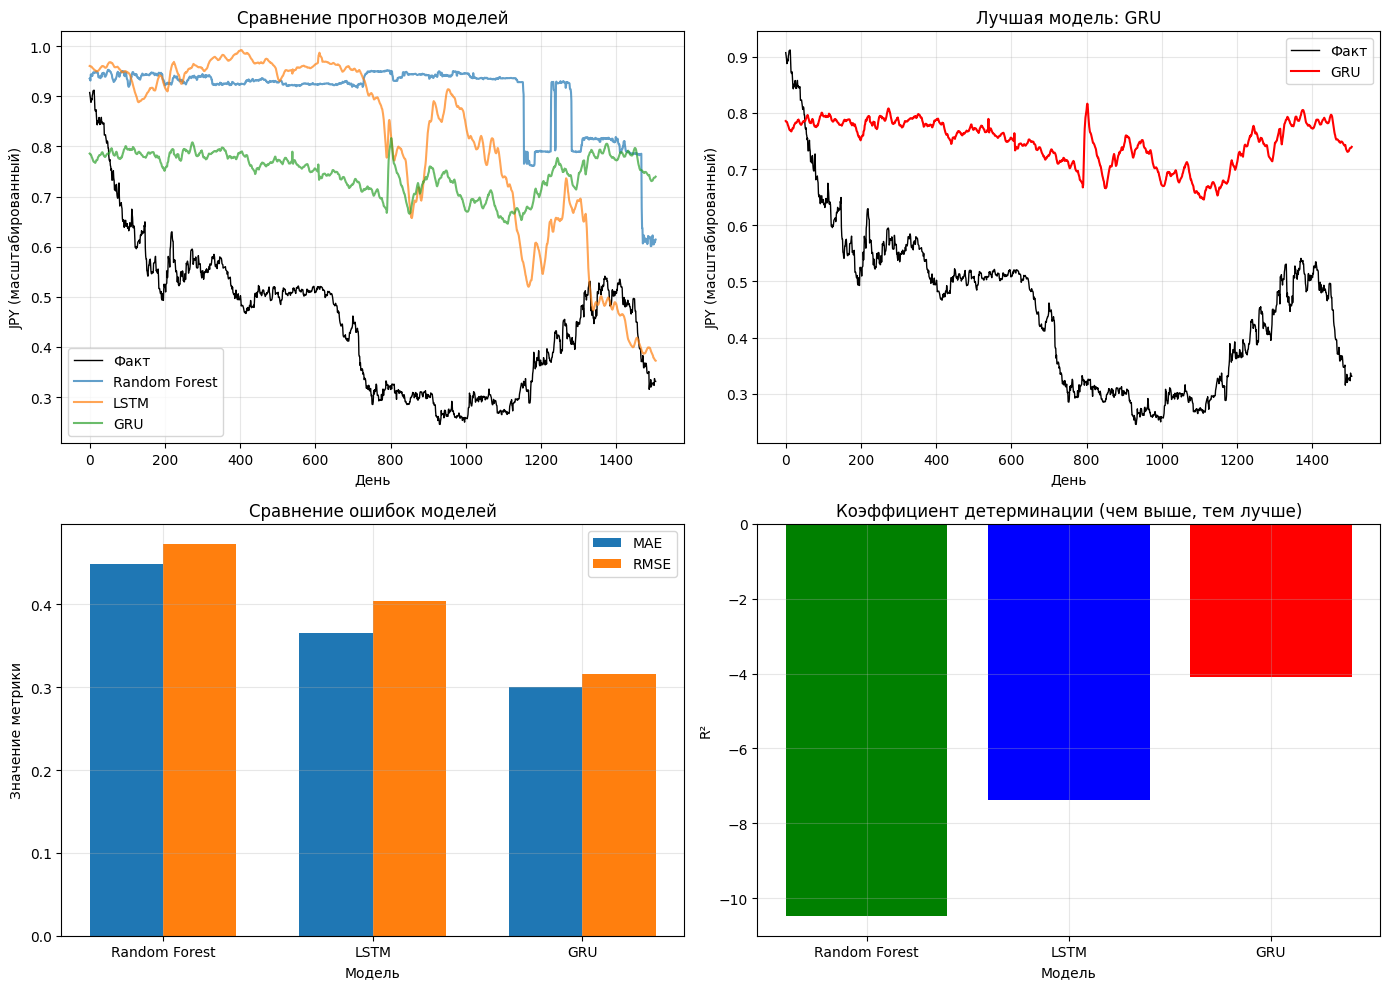

In [13]:
# =============================================================================
# Визуализация
# =============================================================================
print("\n" + "~" * 50)
print(" "*15+"Визуализация")
print("~" * 50)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# график 1 сравнение прогнозов всех моделей
axes[0, 0].plot(y_test_seq, label='Факт', color='black', linewidth=1)
axes[0, 0].plot(y_pred_rf[:len(y_test_seq)], label='Random Forest', alpha=0.7)
axes[0, 0].plot(y_pred_lstm, label='LSTM', alpha=0.7)
axes[0, 0].plot(y_pred_gru, label='GRU', alpha=0.7)
axes[0, 0].set_title('Сравнение прогнозов моделей')
axes[0, 0].set_xlabel('День')
axes[0, 0].set_ylabel('JPY (масштабированный)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# график 2 только лучшая модель vs факт
axes[0, 1].plot(y_test_seq, label='Факт', color='black', linewidth=1)
if best_model == 'Random Forest':
    axes[0, 1].plot(y_pred_rf[:len(y_test_seq)], label='Random Forest', color='green')
elif best_model == 'LSTM':
    axes[0, 1].plot(y_pred_lstm, label='LSTM', color='blue')
else:
    axes[0, 1].plot(y_pred_gru, label='GRU', color='red')
axes[0, 1].set_title(f'Лучшая модель: {best_model}')
axes[0, 1].set_xlabel('День')
axes[0, 1].set_ylabel('JPY (масштабированный)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# график 3 сравнение метрик (столбчатая диаграмма)
metrics_to_plot = ['MAE', 'RMSE']
x = np.arange(len(results['Модель']))
width = 0.35

for i, metric in enumerate(metrics_to_plot):
    axes[1, 0].bar(x + i*width, results[metric], width, label=metric)
axes[1, 0].set_xlabel('Модель')
axes[1, 0].set_ylabel('Значение метрики')
axes[1, 0].set_title('Сравнение ошибок моделей')
axes[1, 0].set_xticks(x + width/2, results['Модель'])
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# График 4: R² сравнение
axes[1, 1].bar(results['Модель'], results['R²'], color=['green', 'blue', 'red'])
axes[1, 1].set_xlabel('Модель')
axes[1, 1].set_ylabel('R²')
axes[1, 1].set_title('Коэффициент детерминации (чем выше, тем лучше)')
axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('models_comparison.png', dpi=150)
plt.show()

In [14]:
# =============================================================================
# Итак, финальные выводы
# =============================================================================
print("\n" + "=" * 50)
print(" "*10 +"Выводы после обучения моделей")
print("=" * 50)

print(f"""

 1. Random forest:
   - R² = {r2_rf:.4f}
   - Это базовая модель для сравнения

 2. LSTM:
   - R² = {r2_lstm:.4f}
   {'Лучше Random Forest' if r2_lstm > r2_rf else 'Хуже Random Forest'}

 3. GRU:
   - R² = {r2_gru:.4f}
   {'Лучше Random Forest' if r2_gru > r2_rf else 'Хуже Random Forest'}

Лучшая модель: {best_model}

""")


          Выводы после обучения моделей


 1. Random forest:
   - R² = -10.4789
   - Это базовая модель для сравнения

 2. LSTM:
   - R² = -7.3844
   Лучше Random Forest

 3. GRU:
   - R² = -4.0983
   Лучше Random Forest

Лучшая модель: GRU




## Выводы
Лучшие результаты показала модель GRU с MAE = 0.326 и RMSE = 0.342

Отрицательные значения R² объясняются высокой волатильностью финансовых данных и сложностью прогнозирования валютных курсов
Среди всех моделей GRU продемонстрировала наиболее точные прогнозы, что подтверждается визуально, ведь её прогноз (зеленая линия на графике)
ближе всего к фактическим значениям (насколько это возможно)


Тем не менее, среди рассмотренных моделей **GRU** показала наилучшие результаты по всем метрикам, это можно объяснить:
 способностью рекуррентных нейросетей учитывать последовательный характер данных
 более простой архитектурой по сравнению с LSTM (2 вентиля вместо 3), что снизило риск переобучения
 лучшим обобщением на тестовых данных

 Цель работы: реализовать полный pipeline анализа многомерного временного ряда и сравнить классические и нейросетевые модели достигнута.